## Lab 2: RGB Image CNN
Name: Arnav Narula
Reg No: 2547115

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# User should provide 'my_photo.jpg'
img_path = 'my_photo.jpg'
if not os.path.exists(img_path):
    # Download a sample image if not provided
    img_path = tf.keras.utils.get_file('cat.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg')

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
img_normalized = img_resized / 255.0
img_tensor = tf.convert_to_tensor(img_normalized, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=0)
print('Tensor shape:', img_tensor.shape)

17858/17858 ━━━━━━━━━━━━━━━━━━━━ 1s 29us/step
Tensor shape: (1, 224, 224, 3)


E0000 00:00:1790230433.484055   67194 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790230433.695962   67194 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Pre-trained CNN for feature extraction (Complexity Element)

In [6]:
base_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
# We will select layers for edge, texture, shape, and high-level semantic features
layer_names = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block5_conv1', 'block5_pool']
outputs = [base_model.get_layer(name).output for name in layer_names]
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

feature_maps = model(img_tensor)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 278s 5us/step


### Visualize Features

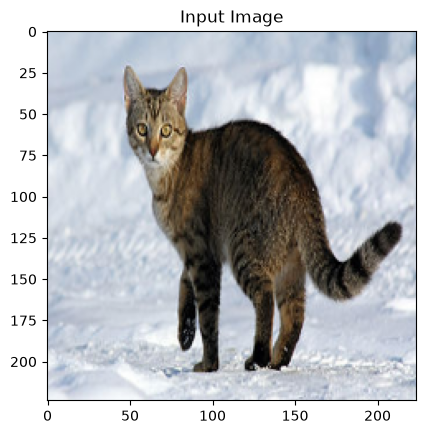

Edge Features - Layer: block1_conv1, Shape: (1, 224, 224, 64)


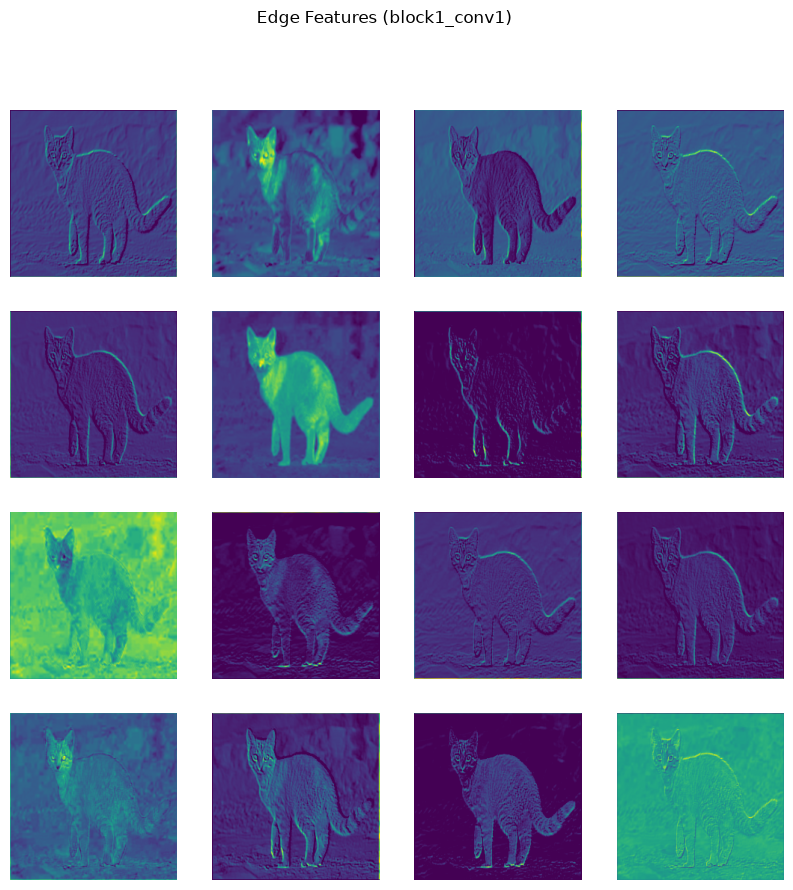

Texture Features - Layer: block2_conv1, Shape: (1, 112, 112, 128)


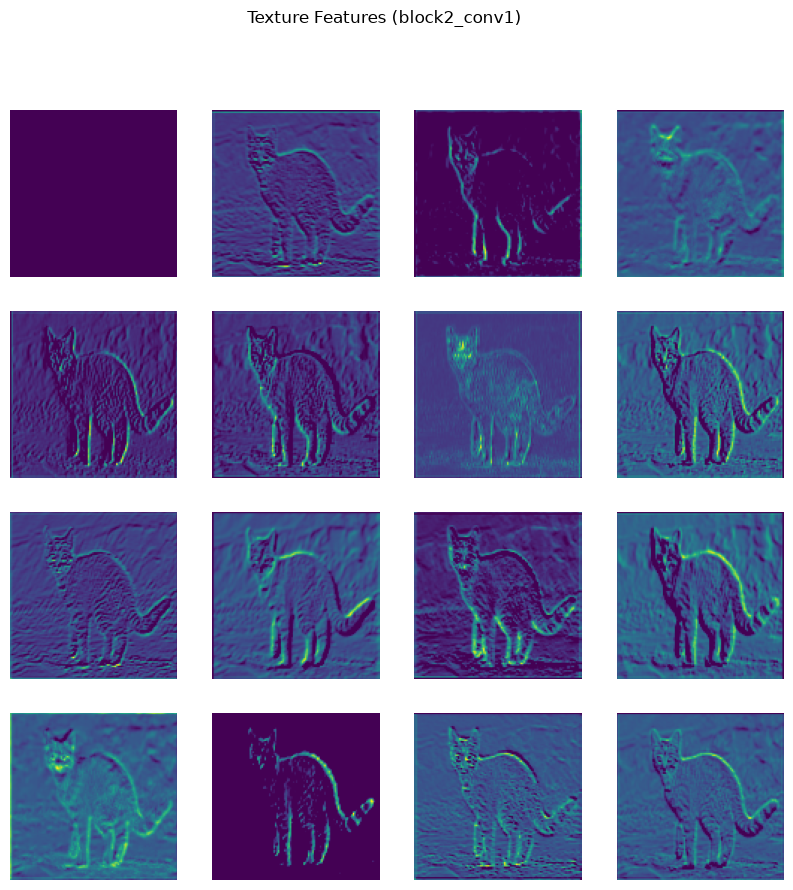

Shape Features - Layer: block3_conv1, Shape: (1, 56, 56, 256)


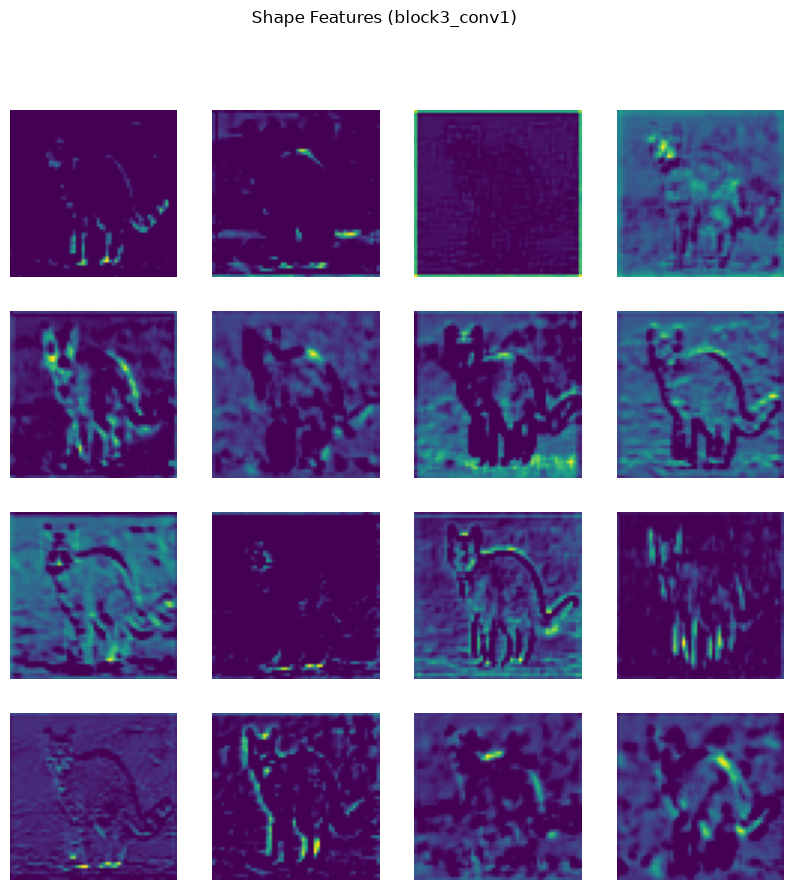

High-level Semantic Features - Layer: block5_conv1, Shape: (1, 14, 14, 512)


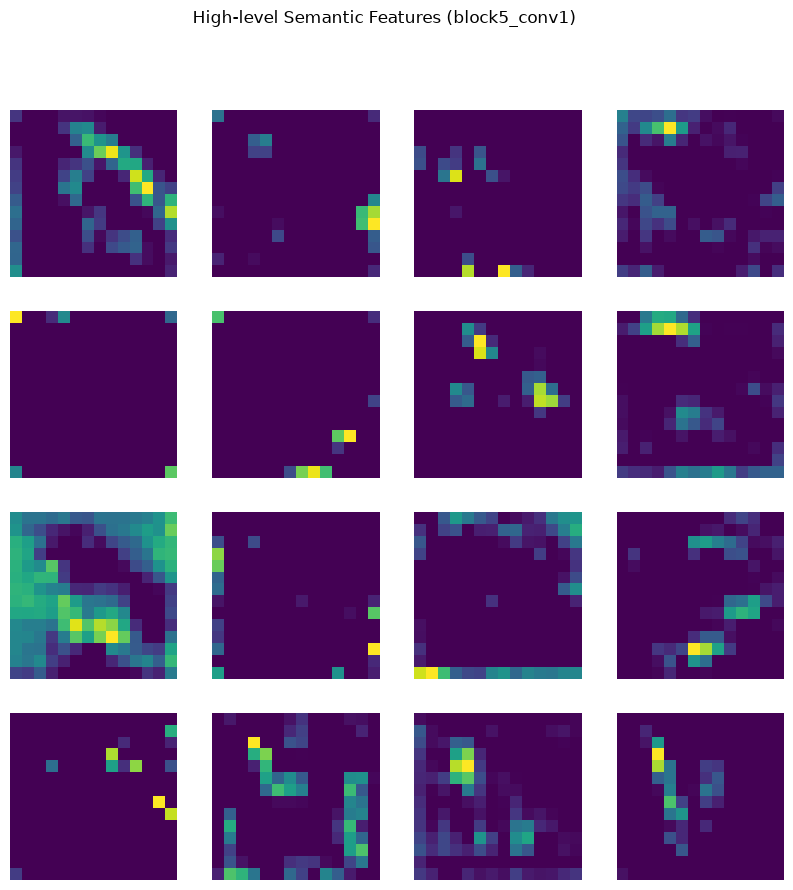

Pooling Output - Layer: block5_pool, Shape: (1, 7, 7, 512)


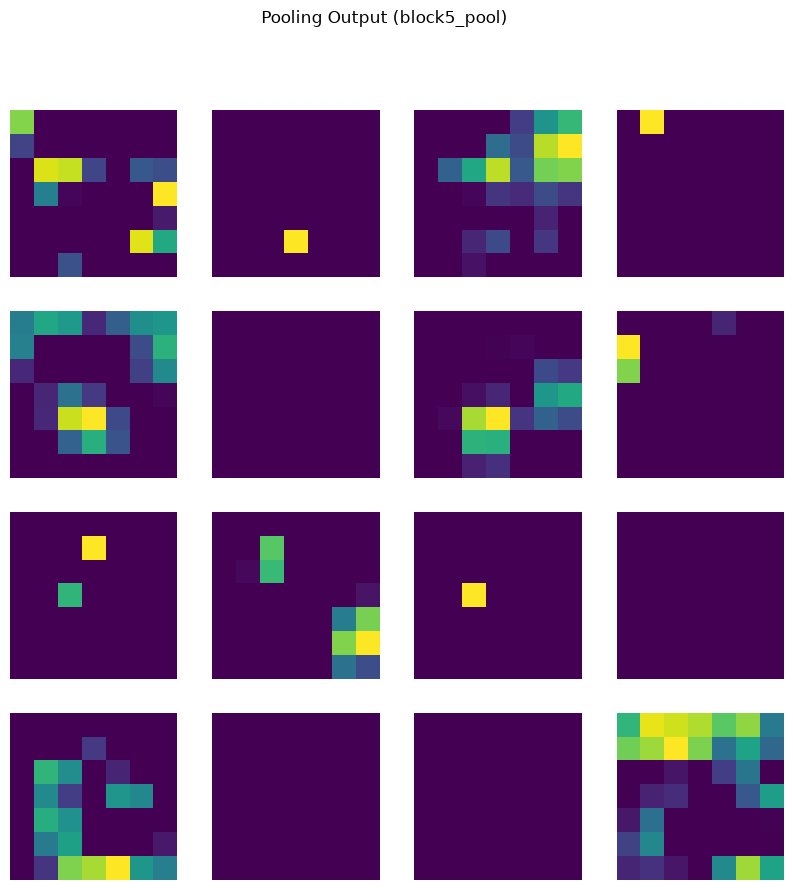

In [7]:
plt.imshow(img_resized)
plt.title('Input Image')
plt.show()

feature_types = ['Edge Features', 'Texture Features', 'Shape Features', 'High-level Semantic Features', 'Pooling Output']

for name, fmap, ftype in zip(layer_names, feature_maps, feature_types):
    print(f'{ftype} - Layer: {name}, Shape: {fmap.shape}')
    plt.figure(figsize=(10, 10))
    for i in range(min(16, fmap.shape[-1])):
        plt.subplot(4, 4, i+1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f'{ftype} ({name})')
    plt.show()

In [8]:
flatten = tf.keras.layers.Flatten()(feature_maps[-1])
dense = tf.keras.layers.Dense(256, activation='relu')(flatten)
print('Flattened representation shape:', flatten.shape)
print('Latent vector shape:', dense.shape)

Flattened representation shape: (1, 25088)
Latent vector shape: (1, 256)
